In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)

In [5]:
cleaned_path = "Datasets/cleaned"

balls = pd.read_csv(f"{cleaned_path}/ball_cleaned.csv")
matches = pd.read_csv(f"{cleaned_path}/matches_cleaned.csv")
players = pd.read_csv(f"{cleaned_path}/player_cleaned.csv")
team_alias = pd.read_csv(f"{cleaned_path}/team_aliases_cleaned.csv")
teams = pd.read_csv(f"{cleaned_path}/teams_data_cleaned.csv")

In [6]:
def basic_eda(df, name):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())

basic_eda(balls, "BALLS")
basic_eda(matches, "MATCHES")
basic_eda(players, "PLAYERS")
basic_eda(teams, "TEAMS")
basic_eda(team_alias, "TEAM ALIASES")


===== BALLS =====
Shape: (278205, 25)

Data Types:
season_id          int64
match_id           int64
batter            object
bowler            object
non_striker       object
team_batting      object
team_bowling      object
over_number        int64
ball_number        int64
batter_runs        int64
extras             int64
total_runs         int64
player_out        object
is_wicket           bool
is_wide_ball        bool
is_no_ball          bool
is_leg_bye          bool
is_bye              bool
wide_ball_runs     int64
no_ball_runs       int64
leg_bye_runs       int64
bye_runs           int64
wicket_kind       object
is_super_over       bool
innings            int64
dtype: object

Missing Values:
season_id              0
match_id               0
batter                 0
bowler                 0
non_striker            0
team_batting           0
team_bowling           0
over_number            0
ball_number            0
batter_runs            0
extras                 0
total_runs       

In [20]:
print("Balls:", balls.shape)
print("Matches:", matches.shape)
print("Players:", players.shape)

Balls: (278205, 25)
Matches: (1169, 17)
Players: (772, 6)


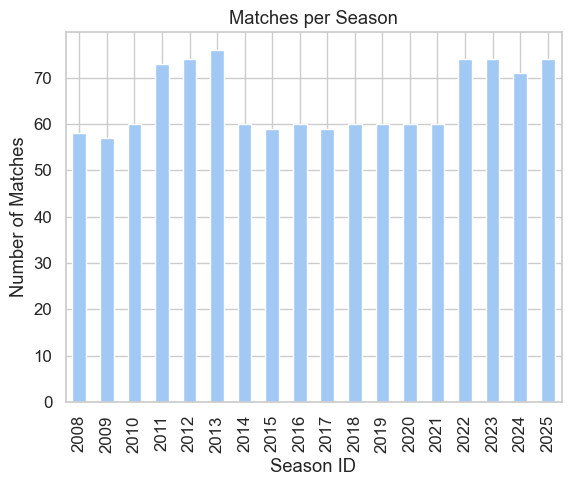

In [21]:
matches_per_season = matches["season_id"].value_counts().sort_index()

plt.figure()
matches_per_season.plot(kind="bar")
plt.title("Matches per Season")
plt.xlabel("Season ID")
plt.ylabel("Number of Matches")
plt.show()

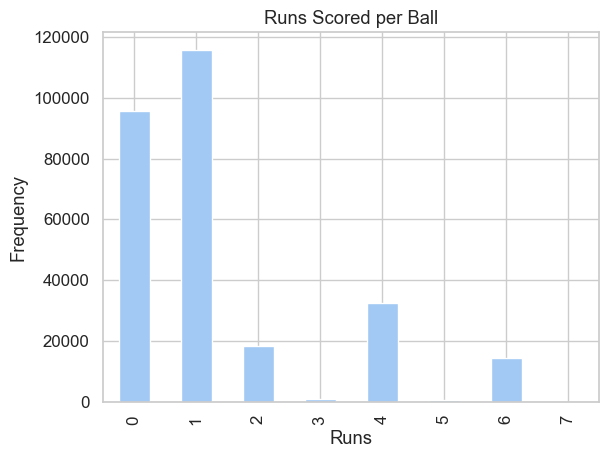

In [22]:
plt.figure()
balls["total_runs"].value_counts().sort_index().plot(kind="bar")
plt.title("Runs Scored per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

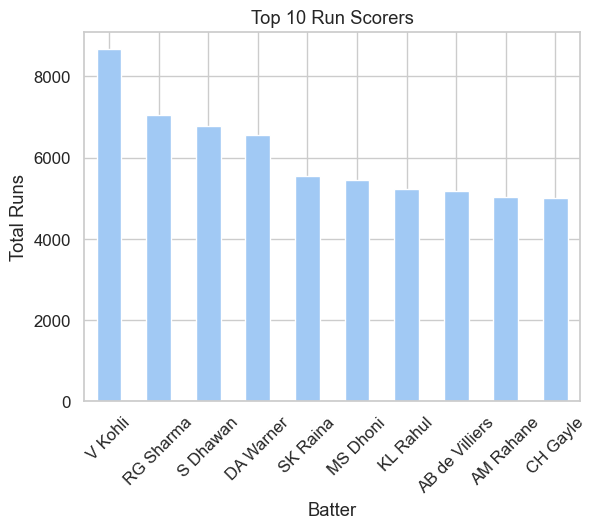

In [23]:
top_batters = (
    balls.groupby("batter")["batter_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_batters.plot(kind="bar")
plt.title("Top 10 Run Scorers")
plt.xlabel("Batter")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.show()

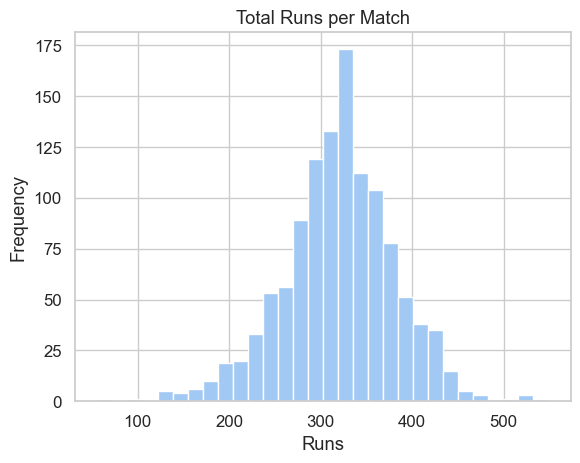

In [24]:
runs_per_match = balls.groupby("match_id")["total_runs"].sum()

plt.figure()
runs_per_match.plot(kind="hist", bins=30)
plt.title("Total Runs per Match")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

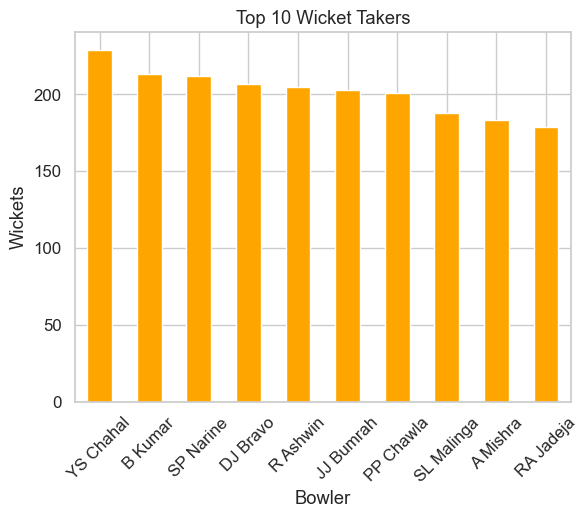

In [25]:
wickets = balls[balls["is_wicket"] == True]

top_bowlers = (
    wickets.groupby("bowler")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_bowlers.plot(kind="bar", color="orange")
plt.title("Top 10 Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45)
plt.show()

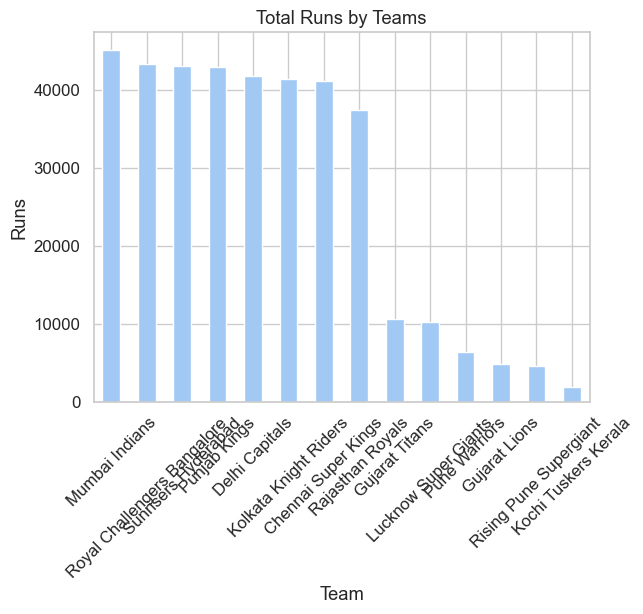

In [26]:
team_runs = (
    balls.groupby("team_batting")["total_runs"]
    .sum()
    .sort_values(ascending=False)
)

team_runs.plot(kind="bar")
plt.title("Total Runs by Teams")
plt.xlabel("Team")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.show()


In [27]:
matches[["win_by_runs", "win_by_wickets"]].describe()

,win_by_runs,win_by_wickets
count,1169.000000,1169.000000
mean,13.761334,3.261762
std,23.564114,3.375717
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,3.000000
75%,19.000000,6.000000
max,146.000000,10.000000


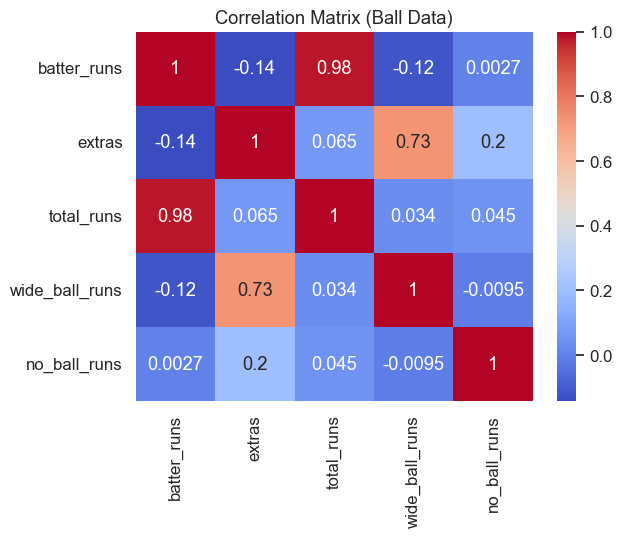

In [28]:
num_cols = [
    "batter_runs", "extras", "total_runs",
    "wide_ball_runs", "no_ball_runs"
]

sns.heatmap(balls[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Ball Data)")
plt.show()